# Работа по задаче предсказания временных рядов на датасете Store Item Demand

## Описание датасета
- Описание файлов
* train.csv — обучающие данные
* test.csv — тестовые данные (обратите внимание: разделение на общедоступные и частные данные зависит от времени).
* sample_submission.csv — пример файла для отправки в правильном формате
- Поля данных
* date — дата продажи. Не учитывает праздничные дни и время работы магазинов.
* store — идентификатор магазина
* item — идентификатор товара
* sales — количество товаров, проданных в конкретном магазине в определённый день.

## Цель
Сделать модель для предсказания временных рядов на датасете Store Item Demand и параллельно сравнить возможности классических ML-моделей (линейная регрессия, случайный лес, градиентный бустинг) и статистических моделей ARIMA/SARIMA.

* Примечание: в рамках этой задачи я не буду участвовать в соревновании Kaggle, так как оно подразумевает грубое предсказание на три месяца вперёд. 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from pmdarima import auto_arima
import time

In [4]:
# Загружаем данные
df_train=pd.read_csv('train.csv')
df_train

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [5]:
print(df_train['store'].nunique())
print(df_train['item'].nunique())

10
50


In [6]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [7]:
df_train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


Датасет содержит 913 000 строк, пропусков нет. Есть только небольшая проблема с типом данных `date`, но в остальном данные в хорошем состоянии. С первого взгляда вижу проблему в том, что датасет разбит на комбинации магазин/товар — это даёт 500 комбинаций, что может негативно сказаться на обучении моделей.

array([[<Axes: title={'center': 'store'}>,
        <Axes: title={'center': 'item'}>],
       [<Axes: title={'center': 'sales'}>, <Axes: >]], dtype=object)

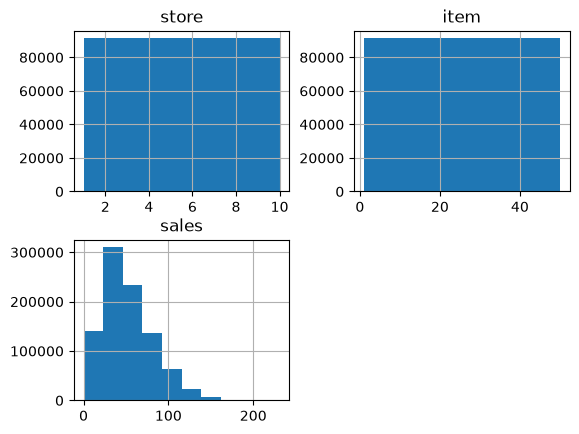

In [8]:
df_train.hist()

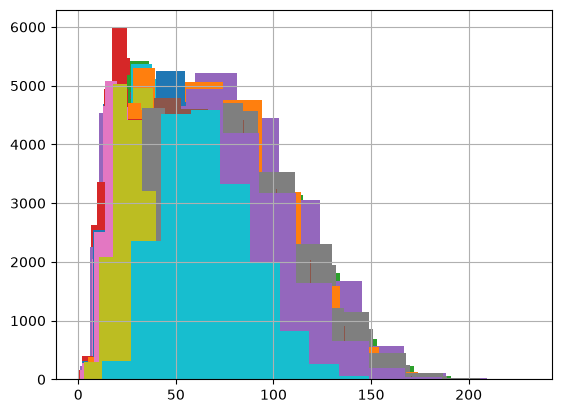

In [9]:
df_train.groupby('item')['sales'].hist()
plt.show()

In [10]:
df_group = df_train.groupby(['item', 'store'])['sales'].mean().reset_index()
df_group[df_group['sales']<15]

,item,store,sales
44,5,5,14.086528
45,5,6,13.893209
46,5,7,12.733844


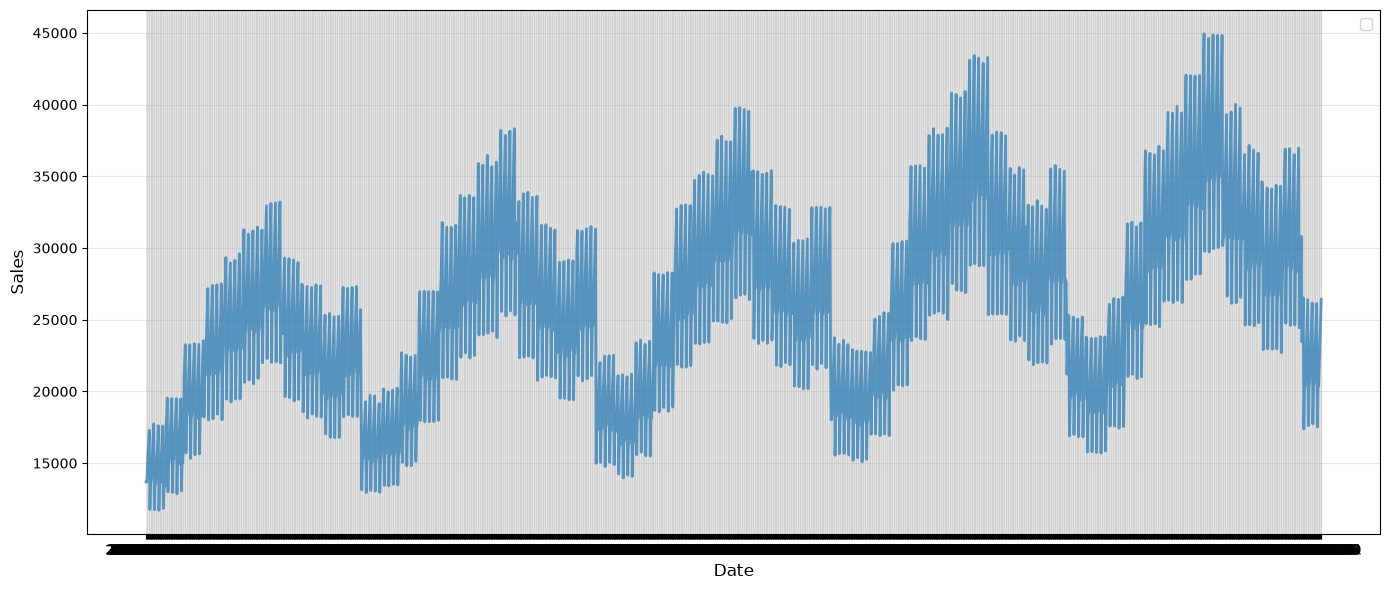

In [11]:
gr = df_train.groupby(['date'])['sales'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(gr['date'], gr['sales'], linewidth=2, alpha=0.7)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
df = df_train.copy()
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek # 0 - Понедельник, 6 - Воскресенье
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_month'] = df['date'].dt.day  

In [13]:
df

,date,store,item,sales,day_of_week,month,year,day_of_month
0,2013-01-01,1,1,13,1,1,2013,1
1,2013-01-02,1,1,11,2,1,2013,2
2,2013-01-03,1,1,14,3,1,2013,3
3,2013-01-04,1,1,13,4,1,2013,4
4,2013-01-05,1,1,10,5,1,2013,5
...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2,12,2017,27
912996,2017-12-28,10,50,59,3,12,2017,28
912997,2017-12-29,10,50,74,4,12,2017,29
912998,2017-12-30,10,50,62,5,12,2017,30


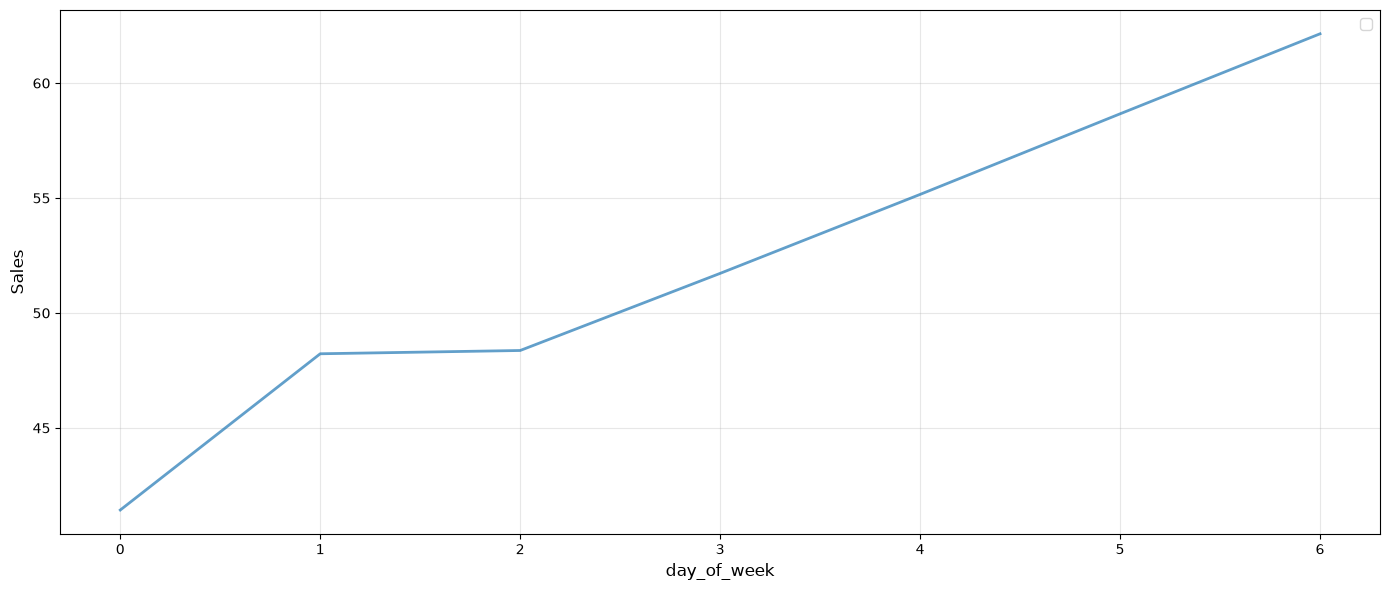

In [14]:
gr = df.groupby(['day_of_week'])['sales'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(gr['day_of_week'], gr['sales'], linewidth=2, alpha=0.7)
plt.xlabel('day_of_week', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

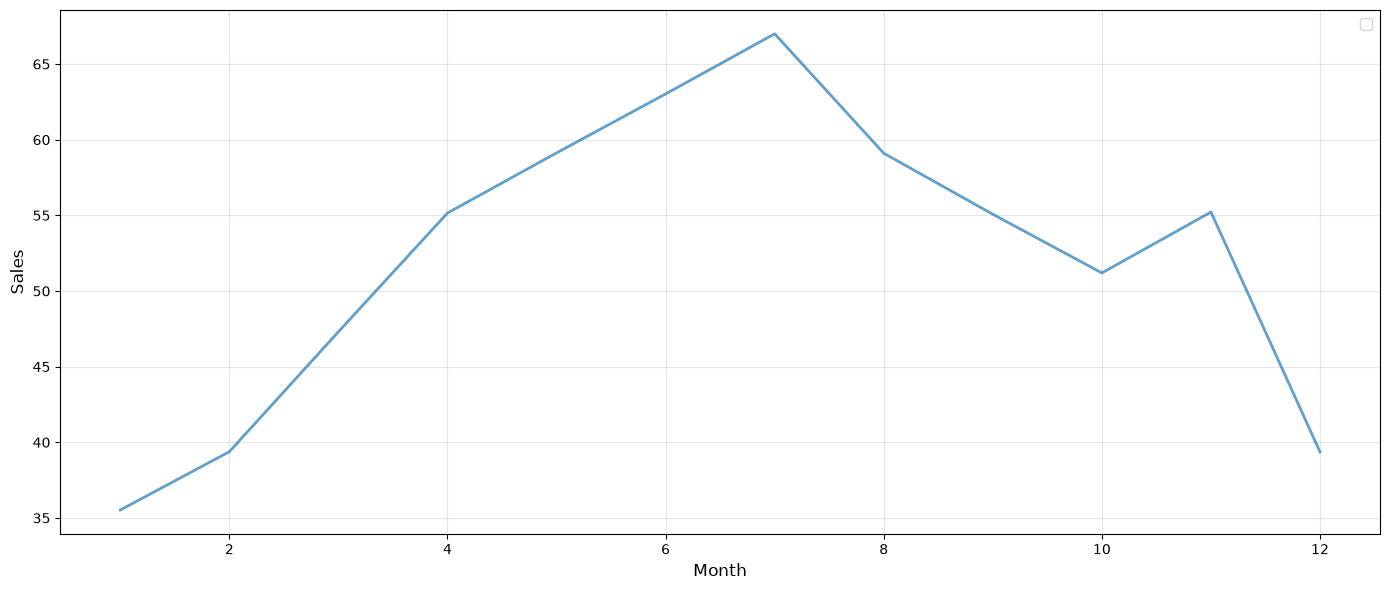

In [15]:
gr = df.groupby(['month'])['sales'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(gr['month'], gr['sales'], linewidth=2, alpha=0.7)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

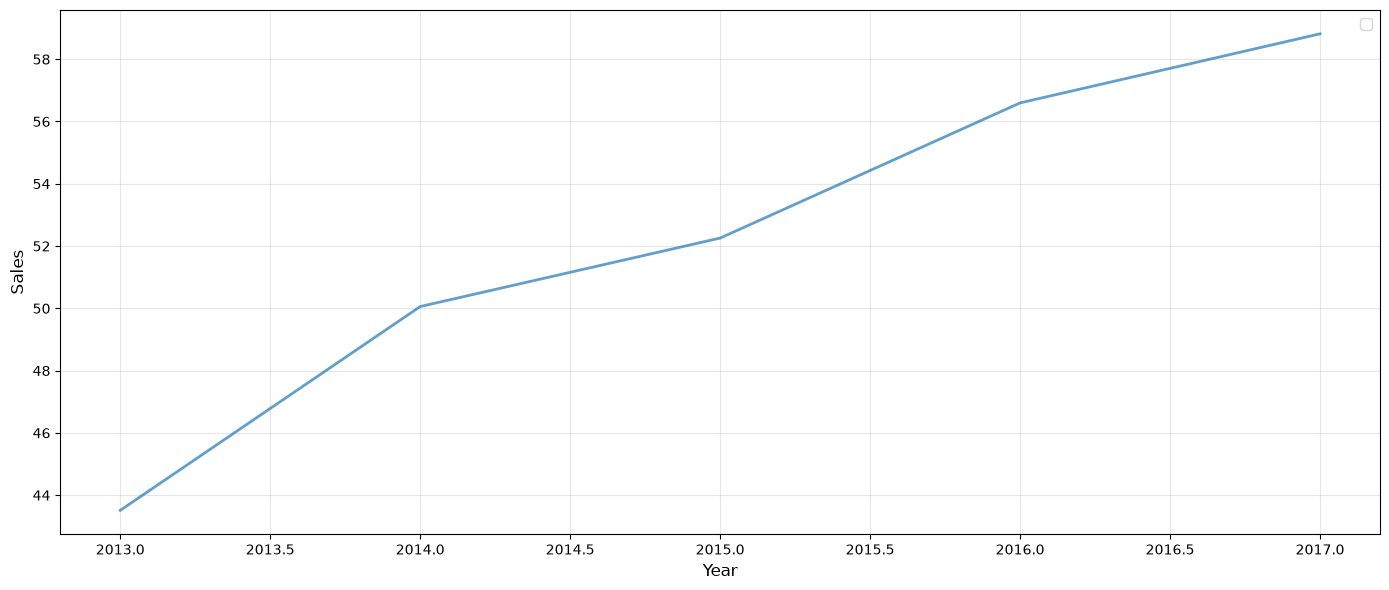

In [16]:
gr = df.groupby(['year'])['sales'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(gr['year'], gr['sales'], linewidth=2, alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

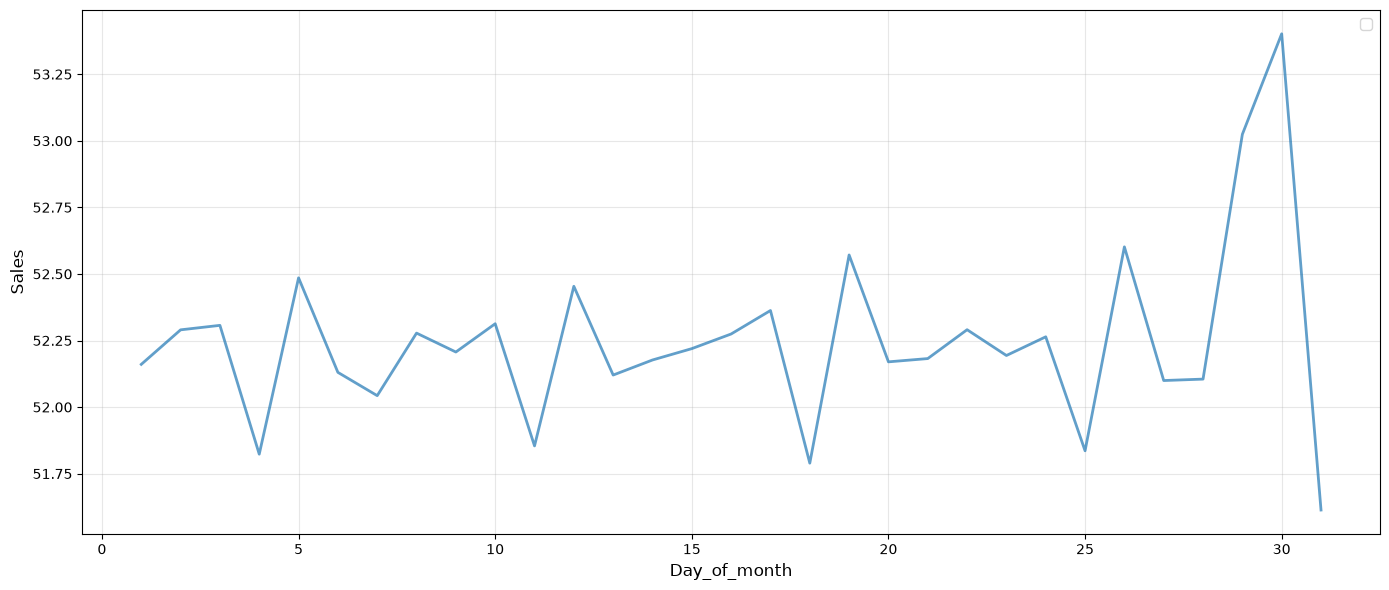

In [17]:
gr = df.groupby(['day_of_month'])['sales'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(gr['day_of_month'], gr['sales'], linewidth=2, alpha=0.7)
plt.xlabel('Day_of_month', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Данный временной ряд имеет:
* общий тренд на повышение (выручка каждый год растёт);
* месячную сезонность (самые загруженные месяцы — с апреля по июль, а конец/начало года — спад);
* недельную тенденцию (к концу недели увеличивается количество продаж);
* по числу в месяце тенденция повторяет недельную, и только конец месяца имеет тренд на повышение.

## Блок линейной модели

### Подготовка данных:
* Создать признаки дня недели, месяца и года
* Перевести дни недели и месяцы в sin/cos, чтобы показать модели, что понедельник и воскресенье — соседние дни
* Добавить общий тренд для данных
* Создать смещения по датам на 1, 7, 14, 30 дней
* Создать скользящие средние на 7, 14, 30 дней

In [349]:
df_train_lr = df_train.copy()
df_train_lr['date'] = pd.to_datetime(df_train_lr['date'])
df_train_lr['day_of_week'] = df_train_lr['date'].dt.dayofweek # 0 - Понедельник, 6 - Воскресенье
df_train_lr['sin_week'] = np.sin(2 * np.pi * df_train_lr['day_of_week'] / 7)
df_train_lr['cos_week'] = np.cos(2 * np.pi * df_train_lr['day_of_week'] / 7)
df_train_lr['month'] = df_train_lr['date'].dt.month
df_train_lr['sin_month'] = np.sin(2 * np.pi * df_train_lr['month'] / 12)
df_train_lr['cos_month'] = np.cos(2 * np.pi * df_train_lr['month'] / 12)
df_train_lr['year'] = df_train_lr['date'].dt.year
# Сортируем по магазинам, товарам и дате
df_train_lr = df_train_lr.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)
# Для каждой пары (store, item) создаем счетчик от 0 до N
df_train_lr['trend'] = df_train_lr.groupby(['store', 'item']).cumcount()
df_train_lr['weekend'] = (df_train_lr['day_of_week'] > 4).astype(int)


In [350]:
df_train_lr

,date,store,item,sales,day_of_week,sin_week,cos_week,month,sin_month,cos_month,year,trend,weekend
0,2013-01-01,1,1,13,1,0.781831,0.623490,1,5.000000e-01,0.866025,2013,0,0
1,2013-01-02,1,1,11,2,0.974928,-0.222521,1,5.000000e-01,0.866025,2013,1,0
2,2013-01-03,1,1,14,3,0.433884,-0.900969,1,5.000000e-01,0.866025,2013,2,0
3,2013-01-04,1,1,13,4,-0.433884,-0.900969,1,5.000000e-01,0.866025,2013,3,0
4,2013-01-05,1,1,10,5,-0.974928,-0.222521,1,5.000000e-01,0.866025,2013,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2,0.974928,-0.222521,12,-2.449294e-16,1.000000,2017,1821,0
912996,2017-12-28,10,50,59,3,0.433884,-0.900969,12,-2.449294e-16,1.000000,2017,1822,0
912997,2017-12-29,10,50,74,4,-0.433884,-0.900969,12,-2.449294e-16,1.000000,2017,1823,0
912998,2017-12-30,10,50,62,5,-0.974928,-0.222521,12,-2.449294e-16,1.000000,2017,1824,1


In [351]:
def create_lag_features(df, lags):
    """Create lag features for each store-item combination."""
    df = df.copy()
    
    for lag in lags:
        df[f'sales_lag_{lag}'] = df.groupby(['store', 'item'])['sales'].shift(lag)
    
    return df

# Define lags
lags = [1, 7, 14, 30]

# Create features
df_train_lr = create_lag_features(df_train_lr, lags)

df_train_lr

,date,store,item,sales,day_of_week,sin_week,cos_week,month,sin_month,cos_month,year,trend,weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30
0,2013-01-01,1,1,13,1,0.781831,0.623490,1,5.000000e-01,0.866025,2013,0,0,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,0.974928,-0.222521,1,5.000000e-01,0.866025,2013,1,0,13.0,NaN,NaN,NaN
2,2013-01-03,1,1,14,3,0.433884,-0.900969,1,5.000000e-01,0.866025,2013,2,0,11.0,NaN,NaN,NaN
3,2013-01-04,1,1,13,4,-0.433884,-0.900969,1,5.000000e-01,0.866025,2013,3,0,14.0,NaN,NaN,NaN
4,2013-01-05,1,1,10,5,-0.974928,-0.222521,1,5.000000e-01,0.866025,2013,4,1,13.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2,0.974928,-0.222521,12,-2.449294e-16,1.000000,2017,1821,0,41.0,51.0,67.0,75.0
912996,2017-12-28,10,50,59,3,0.433884,-0.900969,12,-2.449294e-16,1.000000,2017,1822,0,63.0,63.0,72.0,68.0
912997,2017-12-29,10,50,74,4,-0.433884,-0.900969,12,-2.449294e-16,1.000000,2017,1823,0,59.0,75.0,72.0,76.0
912998,2017-12-30,10,50,62,5,-0.974928,-0.222521,12,-2.449294e-16,1.000000,2017,1824,1,74.0,70.0,52.0,73.0


In [352]:
def create_rolling_features(df, windows):
    """Create rolling window features for each store-item combination."""
    df = df.copy()
    
    for window in windows:
        # Rolling mean
        df[f'rolling_mean_{window}'] = df.groupby(['store', 'item'])['sales'].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
        )
        
        # Rolling std (volatility)
        df[f'rolling_std_{window}'] = df.groupby(['store', 'item'])['sales'].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).std()
        )
    
    return df

# Define windows
windows = [7, 14, 30]

# Create features
df_train_lr = create_rolling_features(df_train_lr, windows)

df_train_lr

,date,store,item,sales,day_of_week,sin_week,cos_week,month,sin_month,cos_month,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
0,2013-01-01,1,1,13,1,0.781831,0.623490,1,5.000000e-01,0.866025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,0.974928,-0.222521,1,5.000000e-01,0.866025,...,13.0,NaN,NaN,NaN,13.000000,NaN,13.000000,NaN,13.000000,NaN
2,2013-01-03,1,1,14,3,0.433884,-0.900969,1,5.000000e-01,0.866025,...,11.0,NaN,NaN,NaN,12.000000,1.414214,12.000000,1.414214,12.000000,1.414214
3,2013-01-04,1,1,13,4,-0.433884,-0.900969,1,5.000000e-01,0.866025,...,14.0,NaN,NaN,NaN,12.666667,1.527525,12.666667,1.527525,12.666667,1.527525
4,2013-01-05,1,1,10,5,-0.974928,-0.222521,1,5.000000e-01,0.866025,...,13.0,NaN,NaN,NaN,12.750000,1.258306,12.750000,1.258306,12.750000,1.258306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2,0.974928,-0.222521,12,-2.449294e-16,1.000000,...,41.0,51.0,67.0,75.0,61.000000,13.576941,63.071429,12.839029,64.633333,10.436948
912996,2017-12-28,10,50,59,3,0.433884,-0.900969,12,-2.449294e-16,1.000000,...,63.0,63.0,72.0,68.0,62.714286,12.841525,62.785714,12.789290,64.233333,10.254295
912997,2017-12-29,10,50,74,4,-0.433884,-0.900969,12,-2.449294e-16,1.000000,...,59.0,75.0,72.0,76.0,62.142857,12.915476,61.857143,12.538293,63.933333,10.271935
912998,2017-12-30,10,50,62,5,-0.974928,-0.222521,12,-2.449294e-16,1.000000,...,74.0,70.0,52.0,73.0,62.000000,12.754084,62.000000,12.673413,63.866667,10.197137


In [353]:
df_train_lr.drop(columns=['day_of_week', 'month'], inplace=True)
df_train_lr

,date,store,item,sales,sin_week,cos_week,sin_month,cos_month,year,trend,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
0,2013-01-01,1,1,13,0.781831,0.623490,5.000000e-01,0.866025,2013,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,0.974928,-0.222521,5.000000e-01,0.866025,2013,1,...,13.0,NaN,NaN,NaN,13.000000,NaN,13.000000,NaN,13.000000,NaN
2,2013-01-03,1,1,14,0.433884,-0.900969,5.000000e-01,0.866025,2013,2,...,11.0,NaN,NaN,NaN,12.000000,1.414214,12.000000,1.414214,12.000000,1.414214
3,2013-01-04,1,1,13,-0.433884,-0.900969,5.000000e-01,0.866025,2013,3,...,14.0,NaN,NaN,NaN,12.666667,1.527525,12.666667,1.527525,12.666667,1.527525
4,2013-01-05,1,1,10,-0.974928,-0.222521,5.000000e-01,0.866025,2013,4,...,13.0,NaN,NaN,NaN,12.750000,1.258306,12.750000,1.258306,12.750000,1.258306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,0.974928,-0.222521,-2.449294e-16,1.000000,2017,1821,...,41.0,51.0,67.0,75.0,61.000000,13.576941,63.071429,12.839029,64.633333,10.436948
912996,2017-12-28,10,50,59,0.433884,-0.900969,-2.449294e-16,1.000000,2017,1822,...,63.0,63.0,72.0,68.0,62.714286,12.841525,62.785714,12.789290,64.233333,10.254295
912997,2017-12-29,10,50,74,-0.433884,-0.900969,-2.449294e-16,1.000000,2017,1823,...,59.0,75.0,72.0,76.0,62.142857,12.915476,61.857143,12.538293,63.933333,10.271935
912998,2017-12-30,10,50,62,-0.974928,-0.222521,-2.449294e-16,1.000000,2017,1824,...,74.0,70.0,52.0,73.0,62.000000,12.754084,62.000000,12.673413,63.866667,10.197137


### Очистка данных
Из-за добавленных смещений в данных появились пропуски. Чтобы они не сломали модель, удалим соответствующие строки: потеряем около месяца данных, но информация по этому периоду сохранится в лагах.

In [354]:
df_train_lr.isnull().sum()

date                   0
store                  0
item                   0
sales                  0
sin_week               0
cos_week               0
sin_month              0
cos_month              0
year                   0
trend                  0
weekend                0
sales_lag_1          500
sales_lag_7         3500
sales_lag_14        7000
sales_lag_30       15000
rolling_mean_7       500
rolling_std_7       1000
rolling_mean_14      500
rolling_std_14      1000
rolling_mean_30      500
rolling_std_30      1000
dtype: int64

In [355]:
len_1 = len(df_train_lr)
df_train_lr_clear = df_train_lr.dropna()
print(len(df_train_lr_clear)/len_1*100)

98.35706462212487


In [356]:
df_train_lr_clear.isnull().sum()

date               0
store              0
item               0
sales              0
sin_week           0
cos_week           0
sin_month          0
cos_month          0
year               0
trend              0
weekend            0
sales_lag_1        0
sales_lag_7        0
sales_lag_14       0
sales_lag_30       0
rolling_mean_7     0
rolling_std_7      0
rolling_mean_14    0
rolling_std_14     0
rolling_mean_30    0
rolling_std_30     0
dtype: int64

Удалили примерно 2% данных, но основную подготовку завершили.

Сейчас в данных есть общий тренд, который просто нумерует дни и представляет собой линию. Но так как реальные тренды могут быть нелинейными, предлагаю добавить `trend_sqrt` и `trend_sq`. Основная идея в том, что линейная модель сама скорректирует веса в сторону реального тренда, а ненужные признаки будут около нуля.

In [357]:
df_train_lr_clear['trend_sqrt'] = np.sqrt(df_train_lr_clear['trend'])
mean_trend = df_train_lr_clear.groupby(['store', 'item'])['trend'].transform('mean')
df_train_lr_clear['trend_sq'] = (df_train_lr_clear['trend'] - mean_trend) ** 2

In [358]:
df_train_lr_clear.columns

Index(['date', 'store', 'item', 'sales', 'sin_week', 'cos_week', 'sin_month',
       'cos_month', 'year', 'trend', 'weekend', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'trend_sqrt', 'trend_sq'],
      dtype='str')

In [359]:
df_train_lr_clear[['sin_week', 'cos_week', 'sin_month',
       'cos_month', 'year', 'trend', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'trend_sqrt', 'trend_sq']].info()

<class 'pandas.DataFrame'>
Index: 898000 entries, 30 to 912999
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   sin_week         898000 non-null  float64
 1   cos_week         898000 non-null  float64
 2   sin_month        898000 non-null  float64
 3   cos_month        898000 non-null  float64
 4   year             898000 non-null  int32  
 5   trend            898000 non-null  int64  
 6   sales_lag_1      898000 non-null  float64
 7   sales_lag_7      898000 non-null  float64
 8   sales_lag_14     898000 non-null  float64
 9   sales_lag_30     898000 non-null  float64
 10  rolling_mean_7   898000 non-null  float64
 11  rolling_std_7    898000 non-null  float64
 12  rolling_mean_14  898000 non-null  float64
 13  rolling_std_14   898000 non-null  float64
 14  rolling_mean_30  898000 non-null  float64
 15  rolling_std_30   898000 non-null  float64
 16  trend_sqrt       898000 non-null  float64
 17  trend_

### Преобразование данных и обучение линейной модели
Мы подготовили основные признаки модели, но для обучения ещё требуется преобразовать категориальные признаки и нормализовать числовые. Также, из-за большого числа магазинов и товаров, предлагаю сгладить таргет с помощью логарифма. Важное замечание: так как мы работаем не с классической регрессией, а с временным рядом, разбивать данные на train/test будем по дате.

In [ ]:
df_train_lr_clear['target_log'] = np.log1p(df_train_lr_clear['sales'])
# 1. Делаем One-Hot Encoding для категорий 
df_ohe = pd.get_dummies(df_train_lr_clear, columns=['store', 'item'], drop_first=True)

# 2. Разделяем фичи на числовые и категориальные
numeric_features = ['sin_week', 'cos_week', 'sin_month',
       'cos_month', 'year', 'trend', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'trend_sqrt', 'trend_sq']

# Собираем названия всех OHE столбцов, которые сгенерировал pandas
categorical_features = [col for col in df_ohe.columns if col.startswith('store_') or col.startswith('item_')]

X_numeric = df_ohe[numeric_features]
X_categorical = df_ohe[categorical_features]
y = df_ohe['target_log']
split_date = '2017-10-01'
# ФИЛЬТРУЕМ ПО КОЛОНКЕ 'date':
mask_train = df_ohe['date'] < split_date
mask_test = df_ohe['date'] >= split_date

# Разбиваем числовые фичи
X_num_train = X_numeric[mask_train]
X_num_test = X_numeric[mask_test]

# Разбиваем категориальные фичи (OHE)
X_cat_train = X_categorical[mask_train]
X_cat_test = X_categorical[mask_test]

# Разбиваем таргет
y_train = y[mask_train]
y_test = y[mask_test]


# 4. НОРМАЛИЗУЕМ ТОЛЬКО ЧИСЛОВЫЕ ФИЧИ
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# Превращаем обратно в датафреймы для удобства склейки
X_num_train_scaled = pd.DataFrame(X_num_train_scaled, columns=numeric_features, index=X_num_train.index)
X_num_test_scaled = pd.DataFrame(X_num_test_scaled, columns=numeric_features, index=X_num_test.index)

# 5. СКЛЕИВАЕМ нормализованные числа и ненормализованные OHE (нули и единицы)
X_train_final = pd.concat([X_num_train_scaled, X_cat_train], axis=1)
X_test_final = pd.concat([X_num_test_scaled, X_cat_test], axis=1)

# 6. Обучаем!
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Предсказываем 
preds_log = model.predict(X_test_final)

# Возвращаем нормальный масштаб для оценки MAE
preds_real = np.expm1(preds_log)
test_real = np.expm1(y_test)

print(f"MAE:  {mean_absolute_error(test_real, preds_real):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_real, preds_real)):.2f}")
print(f"R²:   {r2_score(test_real, preds_real):.4f}")


MAE:  7.83
RMSE: 10.40
R²:   0.8666


Уже на базовой модели получаем неплохие метрики, особенно порадовал R². Посмотрим, как модель подобрала веса для признаков.

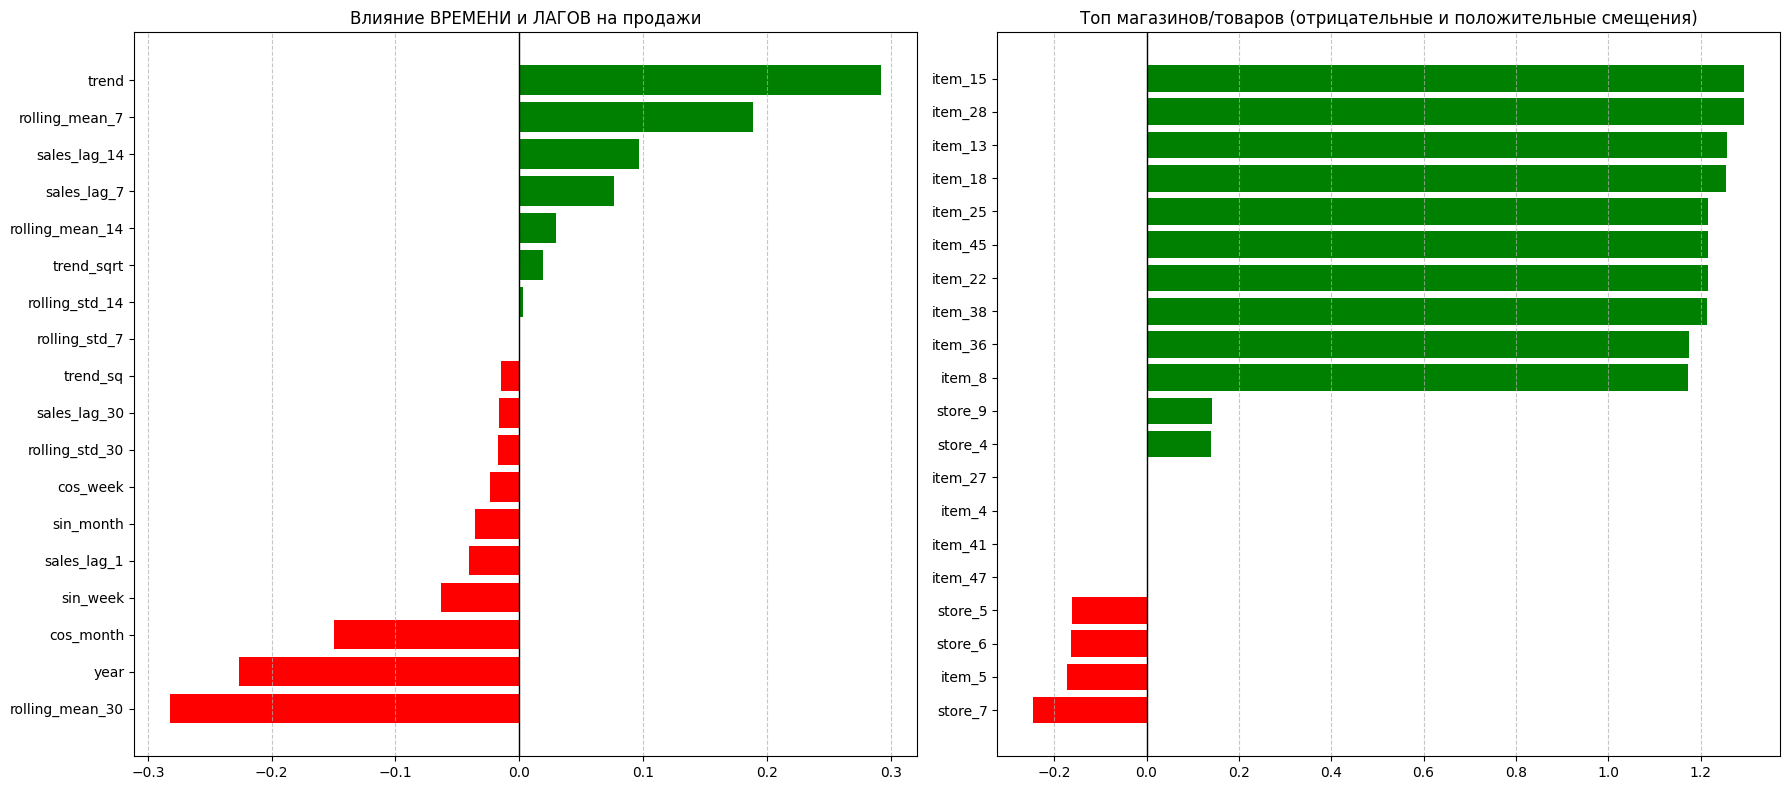

In [ ]:
weights = model.coef_
features = X_train_final.columns

# Создаем датафрейм для удобства
df_weights = pd.DataFrame({'Признак': features, 'Вес': weights})
df_weights = df_weights.sort_values(by='Вес', ascending=True) 

import matplotlib.pyplot as plt

# Разделяем датафрейм с весами
# 1. Все, что НЕ содержит store_ или item_
df_dyn = df_weights[~df_weights['Признак'].str.contains('store_|item_')]
# 2. Только магазины и товары
df_entities = df_weights[df_weights['Признак'].str.contains('store_|item_')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# График 1: Динамика (То, ради чего всё затевалось)
ax1.barh(df_dyn['Признак'], df_dyn['Вес'], color=['red' if w < 0 else 'green' for w in df_dyn['Вес']])
ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_title('Влияние ВРЕМЕНИ и ЛАГОВ на продажи')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# График 2: Топ-10 сущностей (Магазины и Товары) 
top_entities = pd.concat([df_entities.head(10), df_entities.tail(10)])

ax2.barh(top_entities['Признак'], top_entities['Вес'], color=['red' if w < 0 else 'green' for w in top_entities['Вес']])
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_title('Топ магазинов/товаров (отрицательные и положительные смещения)')
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Как и говорил выше, модель сама выбрала тренд, и основной вес имеет именно линейный тренд. Так как сейчас использовалась базовая модель без настройки параметров, попробуем через RandomizedSearchCV подобрать параметры.

In [ ]:
tscv = TimeSeriesSplit(
    n_splits=20, 
    test_size=5000 
)
# 2. Задаем сетку параметров для ElasticNet
# alpha - сила штрафа (чем больше, тем сильнее зануляются веса)
# l1_ratio - баланс между Lasso (1.0) и Ridge (0.0)
param_grid = {
    'alpha': np.logspace(-3, 1, 5), # [0.001, 0.002..., 1, ..., 10]
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 1.0] 
}

# 3. Инициализируем модель
elastic_net = ElasticNet(max_iter=10000, random_state=42) # увеличили итерации для сходимости



# Настраиваем случайный поиск
random_search = RandomizedSearchCV(
    estimator=ElasticNet(max_iter=5000, random_state=42),
    param_distributions=param_grid, 
    n_iter=15,                       
    cv=TimeSeriesSplit(n_splits=5),  
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)


print("Ищем лучшие параметры... (может занять несколько минут)")
random_search.fit(X_train_final, y_train)

# 5. Смотрим результаты
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучшая MAE на кросс-валидации: {-random_search.best_score_:.4f} (в логарифмах)")

# Достаем лучшую модель
best_model = random_search.best_estimator_

Ищем лучшие параметры... (может занять несколько минут)


Лучшие параметры: {'l1_ratio': 0.1, 'alpha': np.float64(0.001)}
Лучшая MAE на кросс-валидации: 0.1689 (в логарифмах)


In [364]:
weights_en = best_model.coef_
df_weights_en = pd.DataFrame({'Признак': X_train_final.columns, 'Вес': weights_en})

# Смотрим, сколько фичей модель занулила (считала мусором)
zeroed_features = df_weights_en[df_weights_en['Вес'] == 0]
print(f"Модель обнулила {len(zeroed_features)} признаков из {len(df_weights_en)}")
print("Обнуленные признаки:")
print(zeroed_features['Признак'].tolist())

Модель обнулила 2 признаков из 76
Обнуленные признаки:
['rolling_std_7', 'rolling_mean_14']


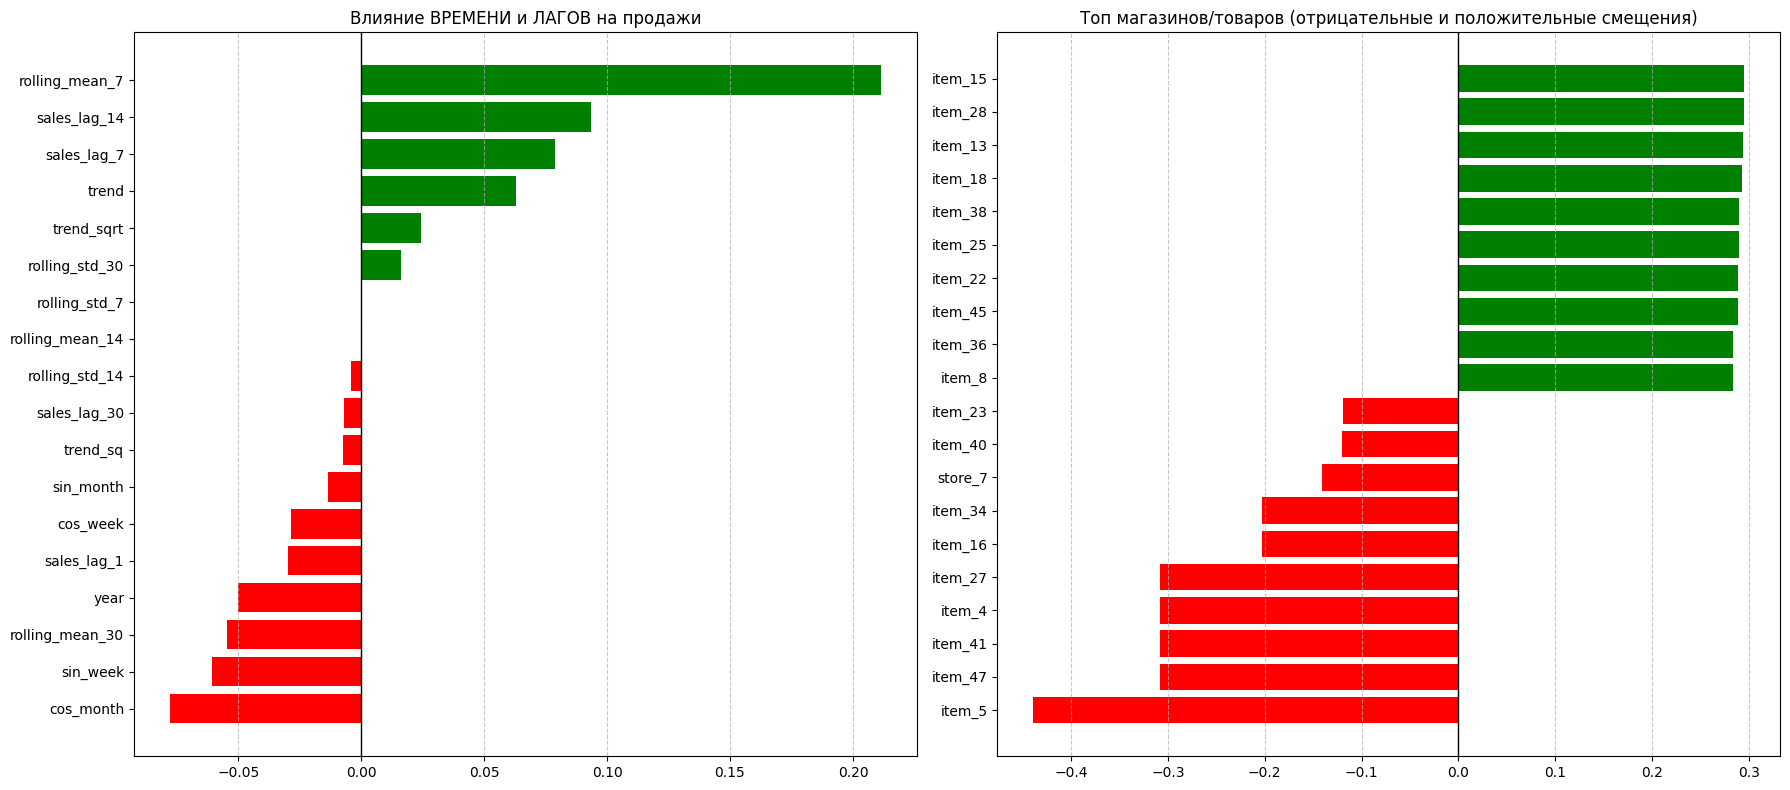

In [ ]:
weights = best_model.coef_
features = X_train_final.columns

# Создаем датафрейм для удобства
df_weights = pd.DataFrame({'Признак': features, 'Вес': weights})
df_weights = df_weights.sort_values(by='Вес', ascending=True) # Сортируем для красоты графика

import matplotlib.pyplot as plt

# Разделяем датафрейм с весами
# 1. Все, что НЕ содержит store_ или item_
df_dyn = df_weights[~df_weights['Признак'].str.contains('store_|item_')]
# 2. Только магазины и товары
df_entities = df_weights[df_weights['Признак'].str.contains('store_|item_')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

#  График 1: Динамика 
ax1.barh(df_dyn['Признак'], df_dyn['Вес'], color=['red' if w < 0 else 'green' for w in df_dyn['Вес']])
ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_title('Влияние ВРЕМЕНИ и ЛАГОВ на продажи')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# График 2: Топ-10 сущностей (Магазины и Товары) 
top_entities = pd.concat([df_entities.head(10), df_entities.tail(10)])

ax2.barh(top_entities['Признак'], top_entities['Вес'], color=['red' if w < 0 else 'green' for w in top_entities['Вес']])
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_title('Топ магазинов/товаров (отрицательные и положительные смещения)')
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Предсказываем 
preds_log = best_model.predict(X_test_final)

# Возвращаем нормальный масштаб для оценки MAE
preds_real = np.expm1(preds_log)
test_real = np.expm1(y_test)

print(f"MAE:  {mean_absolute_error(test_real, preds_real):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_real, preds_real)):.2f}")
print(f"R²:   {r2_score(test_real, preds_real):.4f}")

MAE:  8.05
RMSE: 10.70
R²:   0.8590


В итоге попытка добавить регуляризацию не увенчалась успехом: штрафы сильно занизили общий тренд и обнулили 2 признака, из-за чего метрики только ухудшились. Попробуем убрать признаки, которые модель посчитала излишними, но без штрафов.

MAE:  7.83
RMSE: 10.41
R²:   0.8665


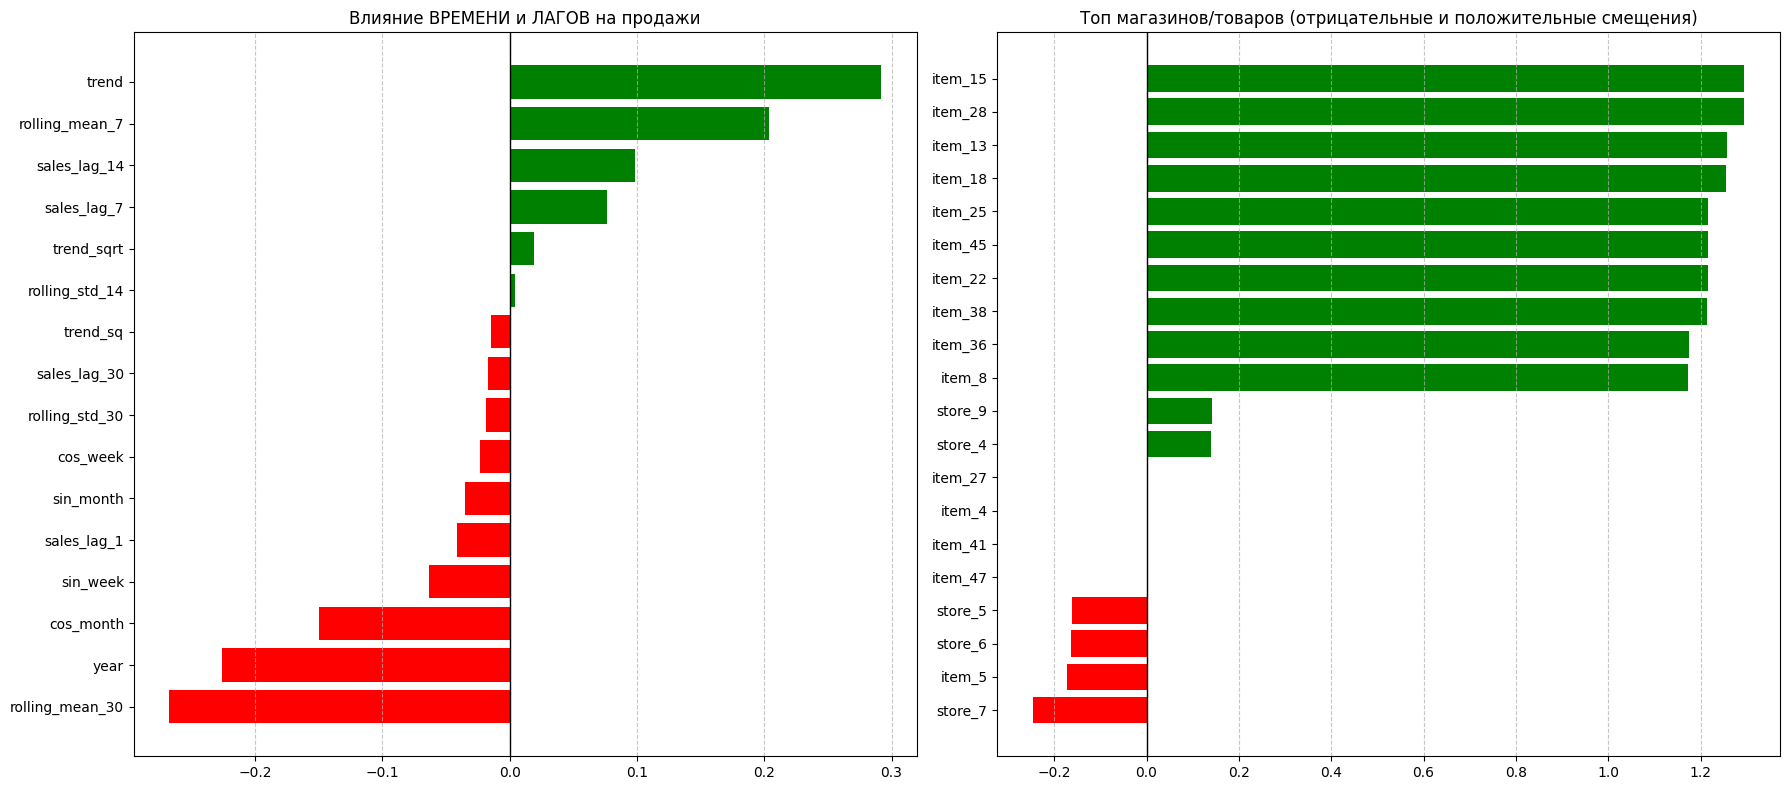

In [ ]:
df_train_lr_clear['target_log'] = np.log1p(df_train_lr_clear['sales'])
# 1. Делаем One-Hot Encoding для категорий 
df_ohe = pd.get_dummies(df_train_lr_clear, columns=['store', 'item'], drop_first=True)

# 2. Разделяем фичи на числовые и категориальные
numeric_features = ['sin_week', 'cos_week', 'sin_month',
       'cos_month', 'year', 'trend', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7',
       'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'trend_sqrt', 'trend_sq']

# Собираем названия всех OHE столбцов, которые сгенерировал pandas
categorical_features = [col for col in df_ohe.columns if col.startswith('store_') or col.startswith('item_')]

X_numeric = df_ohe[numeric_features]
X_categorical = df_ohe[categorical_features]
y = df_ohe['target_log']
split_date = '2017-10-01'

mask_train = df_ohe['date'] < split_date
mask_test = df_ohe['date'] >= split_date

# Разбиваем числовые фичи
X_num_train = X_numeric[mask_train]
X_num_test = X_numeric[mask_test]

# Разбиваем категориальные фичи (OHE)
X_cat_train = X_categorical[mask_train]
X_cat_test = X_categorical[mask_test]

# Разбиваем таргет
y_train = y[mask_train]
y_test = y[mask_test]


# 4. НОРМАЛИЗУЕМ ТОЛЬКО ЧИСЛОВЫЕ ФИЧИ
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# Превращаем обратно в датафреймы для удобства склейки
X_num_train_scaled = pd.DataFrame(X_num_train_scaled, columns=numeric_features, index=X_num_train.index)
X_num_test_scaled = pd.DataFrame(X_num_test_scaled, columns=numeric_features, index=X_num_test.index)

# 5. СКЛЕИВАЕМ нормализованные числа и ненормализованные OHE (нули и единицы)
X_train_final = pd.concat([X_num_train_scaled, X_cat_train], axis=1)
X_test_final = pd.concat([X_num_test_scaled, X_cat_test], axis=1)
model_final = LinearRegression()
model_final.fit(X_train_final, y_train)
# Предсказываем 
preds_log = model_final.predict(X_test_final)

# Возвращаем нормальный масштаб для оценки MAE
preds_real = np.expm1(preds_log)
test_real = np.expm1(y_test)

print(f"MAE:  {mean_absolute_error(test_real, preds_real):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_real, preds_real)):.2f}")
print(f"R²:   {r2_score(test_real, preds_real):.4f}")
weights = model_final.coef_
features = X_train_final.columns

# Создаем датафрейм для удобства
df_weights = pd.DataFrame({'Признак': features, 'Вес': weights})
df_weights = df_weights.sort_values(by='Вес', ascending=True) 


# Разделяем датафрейм с весами
# 1. Все, что НЕ содержит store_ или item_
df_dyn = df_weights[~df_weights['Признак'].str.contains('store_|item_')]
# 2. Только магазины и товары
df_entities = df_weights[df_weights['Признак'].str.contains('store_|item_')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# График 1: Динамика 
ax1.barh(df_dyn['Признак'], df_dyn['Вес'], color=['red' if w < 0 else 'green' for w in df_dyn['Вес']])
ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_title('Влияние ВРЕМЕНИ и ЛАГОВ на продажи')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# График 2: Топ-10 сущностей (Магазины и Товары)
top_entities = pd.concat([df_entities.head(10), df_entities.tail(10)])

ax2.barh(top_entities['Признак'], top_entities['Вес'], color=['red' if w < 0 else 'green' for w in top_entities['Вес']])
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_title('Топ магазинов/товаров (отрицательные и положительные смещения)')
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Отличий от первой модели почти нет — попробуем посмотреть детальнее на ошибки нашей модели.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Получаем предсказания 
preds_log = model_final.predict(X_test_final)

# 2. Возвращаем их в нормальные единицы 
preds_real = np.expm1(preds_log)
y_test_real = np.expm1(y_test)

# 3. Собираем красивый датафрейм
# Берем оригинальные колонки store и item по индексам тестовой выборки
results_df = df_train_lr_clear.loc[y_test.index, ['store', 'item']].copy()

# Добавляем реальные значения, предсказания и саму ошибку
results_df['y_real'] = y_test_real.values
results_df['pred_real'] = preds_real
results_df['error'] = abs(results_df['y_real'] - results_df['pred_real']) 

results_df.head()

,store,item,y_real,pred_real,error
1734,1,1,21.0,21.754759,0.754759
1735,1,1,12.0,19.358044,7.358044
1736,1,1,18.0,18.678486,0.678486
1737,1,1,15.0,19.293208,4.293208
1738,1,1,20.0,20.203135,0.203135


In [369]:
preds_real

array([21.75475932, 19.35804422, 18.67848576, ..., 78.38019506,
       72.69965011, 80.76912452], shape=(46000,))

In [ ]:
# Считаем процент ошибки 
results_df['pct_error'] = np.where(
    results_df['y_real'] > 0,
    abs((results_df['y_real'] - results_df['pred_real']) / results_df['y_real']) * 100,
    0 
)

# Теперь смотрим MAPE по товарам
mape_by_item = results_df.groupby('item')['pct_error'].mean().sort_values(ascending=False)

print("\nТоп-5 товаров по проценту ошибки (MAPE):")
print(mape_by_item.head().round(1), "%")
print("\nСредний процент ошибки (MAPE):")
print(mape_by_item.mean().round(1), "%")


Топ-5 товаров по проценту ошибки (MAPE):
item
41    23.0
5     22.7
27    21.4
1     21.3
4     21.3
Name: pct_error, dtype: float64 %

Средний процент ошибки (MAPE):
15.8 %


В среднем наша модель ошибается на ~16%, но на некоторых товарах ошибка достигает 23%. Есть гипотеза, что линейной модели сложно работать с комбинациями магазин/товар и общая модель может плохо улавливать товары с сезонностью, отличной от остальных. Предлагаю обучить не одну большую модель, а 500 поменьше, чтобы модель подстроилась под различные сезонности разных товаров.

In [ ]:
# Создадим пустой датафрейм, куда будем складывать предсказания
predictions = pd.DataFrame()

grouped = df_train_lr_clear.groupby(['store', 'item'])

features = ['sin_week', 'cos_week', 'sin_month',
       'cos_month', 'year', 'trend', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'trend_sqrt', 'trend_sq']

for name, group in grouped:
    store, item = name
    
    
    # 1. Подготовка X и y 
    X = group[features] 
    y = np.log1p(group['sales'])
    
    # 2. Разбивка на трейн/тест ВНУТРИ этой группы 
    split_idx = len(group) - 30
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # 3. Нормализация 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Обучение 
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # 5. Предсказание и обратное преобразование
    preds_log = model.predict(X_test_scaled)
    preds_real = np.expm1(preds_log)
    
    # 6. Сохраняем результат
    temp_df = pd.DataFrame({
        'store': store,
        'item': item,
        'y_real': np.expm1(y_test),
        'pred_real': preds_real
    }, index=y_test.index)
    
    predictions = pd.concat([predictions, temp_df])

# 7. Считаем общий MAPE по всем 500 моделям
predictions['pct_error'] = np.where(
    predictions['y_real'] > 0,
    abs((predictions['y_real'] - predictions['pred_real']) / predictions['y_real']) * 100,
    0
)

print(f"Общий MAPE 500 локальных моделей: {predictions['pct_error'].mean():.1f}%")

Общий MAPE 500 локальных моделей: 18.0%


In [372]:
predictions

,store,item,y_real,pred_real,pct_error
1796,1,1,16.0,22.945856,43.411599
1797,1,1,31.0,20.556440,33.688904
1798,1,1,7.0,15.553165,122.188072
1799,1,1,20.0,16.471751,17.641245
1800,1,1,17.0,18.473868,8.669809
...,...,...,...,...,...
912995,10,50,63.0,61.948129,1.669636
912996,10,50,59.0,68.531315,16.154771
912997,10,50,74.0,75.326312,1.792314
912998,10,50,62.0,69.323141,11.811517


In [ ]:
local_mape = predictions.groupby(['store', 'item'])['pct_error'].mean().reset_index()
local_mape[local_mape['pct_error']>25]
len(local_mape[local_mape['pct_error']>25])


54

В ходе эксперимента была проверена гипотеза о переходе к локальным моделям (обучение отдельной регрессии для каждой пары «магазин–товар»). Несмотря на достаточный объём данных для каждой комбинации (~1800 наблюдений), подход показал деградацию метрики на 2.2% (с 15.8% до 18% MAPE).

Анализ ошибок показал, что деградация вызвана не редким спросом, а локальным переобучением (overfitting) на специфические для конкретной точки шумы (локальные аномалии, отсутствие товара на полке). Глобальная модель оказалась более устойчивой, так как извлекает общие паттерны поведения товаров по всей сети, выступая естественным регуляризатором. Эксперимент подтвердил выбор архитектуры Global Model как оптимальной для данного датасета.

## Блок Модели деревьев

### Подготовка данных
Подготовка данных для моделей деревьев не сильно отличается от линейной модели, поэтому долго останавливаться на этом не буду — укажу только основные отличия:
* sin/cos убраны, так как для дерева 0 и 6 равнозначны;
* убраны нелинейные тренды `sq` и `sqrt`;
* добавлен `day_of_month` с числом дня.

In [ ]:
df_train_tr = df_train.copy()
df_train_tr['date'] = pd.to_datetime(df_train_tr['date'])
df_train_tr['day_of_week'] = df_train_tr['date'].dt.dayofweek # 0 - Понедельник, 6 - Воскресенье
df_train_tr['day_of_month'] = df_train_tr['date'].dt.day  
df_train_tr['month'] = df_train_tr['date'].dt.month
df_train_tr['year'] = df_train_tr['date'].dt.year
df_train_tr['weekend'] = (df_train_tr['day_of_week'] > 4).astype(int)
# Сортируем по магазинам, товарам и дате
df_train_tr = df_train_tr.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)
# Для каждой пары (store, item) создаем счетчик от 0 до N
df_train_tr['trend'] = df_train_tr.groupby(['store', 'item']).cumcount()


lags = [1, 7, 14, 30]

# Create features
df_train_tr = create_lag_features(df_train_tr, lags)

# Define windows
windows = [7, 14, 30]

# Create features
df_train_tr = create_rolling_features(df_train_tr, windows)
df_train_tr_clear = df_train_tr.dropna()

df_train_tr_clear['target_log'] = np.log1p(df_train_tr_clear['sales'])
# 1. Делаем One-Hot Encoding для категорий 
df_ohe = pd.get_dummies(df_train_tr_clear, columns=['store', 'item'], drop_first=True)
# 2. Разделяем фичи на числовые и категориальные
numeric_features = ['year','sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'weekend', 'month', 'day_of_week', 'day_of_month', 'trend']

# Собираем названия всех OHE столбцов, которые сгенерировал pandas
categorical_features = [col for col in df_ohe.columns if col.startswith('store_') or col.startswith('item_')]

X_numeric = df_ohe[numeric_features]
X_categorical = df_ohe[categorical_features]
y = df_ohe['target_log']
split_date = '2017-10-01'

mask_train = df_ohe['date'] < split_date
mask_test = df_ohe['date'] >= split_date

# Разбиваем числовые фичи
X_num_train = X_numeric[mask_train]
X_num_test = X_numeric[mask_test]

# Разбиваем категориальные фичи (OHE)
X_cat_train = X_categorical[mask_train]
X_cat_test = X_categorical[mask_test]

# Разбиваем таргет
y_train = y[mask_train]
y_test = y[mask_test]

# 5. СКЛЕИВАЕМ нормализованные числа и ненормализованные OHE (нули и единицы)
X_train_final = pd.concat([X_num_train, X_cat_train], axis=1)
X_test_final = pd.concat([X_num_test, X_cat_test], axis=1)

In [375]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 852000 entries, 30 to 912907
Data columns (total 74 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   year             852000 non-null  int32  
 1   sales_lag_1      852000 non-null  float64
 2   sales_lag_7      852000 non-null  float64
 3   sales_lag_14     852000 non-null  float64
 4   sales_lag_30     852000 non-null  float64
 5   rolling_mean_7   852000 non-null  float64
 6   rolling_std_7    852000 non-null  float64
 7   rolling_mean_14  852000 non-null  float64
 8   rolling_std_14   852000 non-null  float64
 9   rolling_mean_30  852000 non-null  float64
 10  rolling_std_30   852000 non-null  float64
 11  weekend          852000 non-null  int64  
 12  month            852000 non-null  int32  
 13  day_of_week      852000 non-null  int32  
 14  day_of_month     852000 non-null  int32  
 15  trend            852000 non-null  int64  
 16  store_2          852000 non-null  bool   
 17  store_

In [ ]:
# 1. LightGBM
print("Обучение LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train_final, y_train)
preds_lgb_log = lgb_model.predict(X_test_final)
preds_lgb_real = np.expm1(preds_lgb_log)

# 2. Random Forest 
print("Обучение Random Forest... (может занять 5-10 минут)")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
preds_rf_log = rf_model.predict(X_test_final)
preds_rf_real = np.expm1(preds_rf_log)

# 3. Оценка
y_test_real = np.expm1(y_test)

# Защита от нулей в MAPE 
mask_for_mape = y_test_real > 0
mape_lgb = mean_absolute_percentage_error(y_test_real[mask_for_mape], preds_lgb_real[mask_for_mape])
mape_rf = mean_absolute_percentage_error(y_test_real[mask_for_mape], preds_rf_real[mask_for_mape])
print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"LightGBM MAPE: {mape_lgb:.4f} ({mape_lgb*100:.2f}%)")
print(f"Random Forest MAPE: {mape_rf*100:.2f}%")
print(f" Линейная Регрессия MAPE: 15.8%")

Обучение LightGBM...
Обучение Random Forest... (может занять 5-10 минут)

=== РЕЗУЛЬТАТЫ ===
LightGBM MAPE: 0.1286 (12.86%)
Random Forest MAPE: 13.86%
 Линейная Регрессия MAPE: 15.8%


Ещё даже без настроек деревья уже обходят линейную модель по метрикам; особенно порадовал LightGBM с 13% MAPE. Возможно, реальные метрики лучше. Есть гипотеза, что из-за того что деревья глобально плохо работают с трендом, дальние значения теста (напоминаю: в тестовой выборке данные за 3 месяца) получили худшие значения, чем ближние. Попробуем посмотреть метрики за первый и последний месяц теста.

In [ ]:
y_test_real = np.expm1(y_test)

# 1. Первые 30 дней теста
mape_lgb_first_30 = mean_absolute_percentage_error(y_test_real[:15000], preds_lgb_real[:15000])

# 2. Последние 30 дней теста 
mape_lgb_last_30 = mean_absolute_percentage_error(y_test_real[-15000:], preds_lgb_real[-15000:])

print(f"LightGBM MAPE (первые 30 дней): {mape_lgb_first_30*100:.2f}%")
print(f"LightGBM MAPE (последние 30 дней): {mape_lgb_last_30*100:.2f}%")


LightGBM MAPE (первые 30 дней): 12.10%
LightGBM MAPE (последние 30 дней): 12.18%


В целом нет, разница выглядит больше как статистический шум, возможно для бустинга особо нет проблемы с предсказанием на t90, но все-равно лучше дообучать модель по мере добавления данных

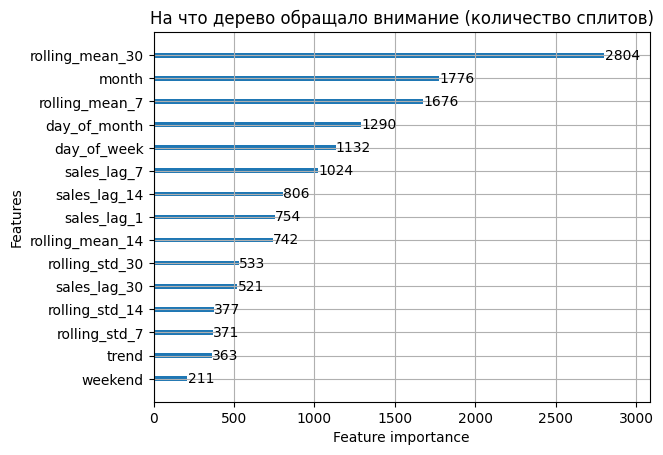

In [378]:
lgb.plot_importance(lgb_model, max_num_features=15, importance_type='split')
plt.title("На что дерево обращало внимание (количество сплитов)")
plt.show()

Модель в основном смотрит на среднее за последние 30 дней и месяц. Попробуем задать модели жёсткие ограничения при обучении.

In [ ]:
import lightgbm as lgb

# "Робастная" конфигурация для временных рядов
lgb_model_robust = lgb.LGBMRegressor(
    # 1. ОГРАНИЧЕНИЕ СЛОЖНОСТИ (Самое важное!)
    max_depth=5,              # Запрещаем глубокие деревья (было без ограничений)
    num_leaves=15,            # Максимальное количество конечных узлов (было 31)
    min_child_samples=100,    # Минимум 100 строк в листе (было 20). Не даст строить правила для 5 случайных дней.
    
    # 2. ШТРАФЫ ЗА СЛОЖНОСТЬ (L1/L2 регуляризация)
    reg_alpha=1.0,            # L1 штраф (Lasso) - занулит бесполезные ветки
    reg_lambda=1.0,           # L2 штраф (Ridge) - не даст весам улететь в космос
    
    # 3. СЛУЧАЙНОСТЬ (Декорреляция деревьев)
    colsample_bytree=0.7,     # Каждое дерево использует только 70% фичей (не будет зависеть от rolling_mean_30 на 100%)
    subsample=0.7,            # Каждое дерево обучается только на 70% строк
    
    # 4. ОБУЧЕНИЕ
    learning_rate=0.03,       # Делаем шаги мелкими. Требует больше деревьев, но точнее.
    n_estimators=1000,        # Увеличим количество деревьев, так как шаг стал мелким
    random_state=42,
    n_jobs=-1
)

print("Обучение регуляризованного LightGBM...")
lgb_model_robust.fit(X_train_final, y_train)

# Предсказание
preds_robust_log = lgb_model_robust.predict(X_test_final)
preds_robust_real = np.expm1(preds_robust_log)

# Оценка по отрезкам (смотрим, побороли ли инерцию)
mask_for_mape = y_test_real > 0

mape_robust_first_30 = mean_absolute_percentage_error(y_test_real[:15000][mask_for_mape[:15000]], preds_robust_real[:15000][mask_for_mape[:15000]])
mape_robust_last_30 = mean_absolute_percentage_error(y_test_real[-15000:][mask_for_mape[-15000:]], preds_robust_real[-15000:][mask_for_mape[-15000:]])
mape_robust_total = mean_absolute_percentage_error(y_test_real[mask_for_mape], preds_robust_real[mask_for_mape])

print(f"\n=== РЕЗУЛЬТАТЫ ROBUST LightGBM ===")
print(f"Общий MAPE: {mape_robust_total*100:.2f}%")
print(f"Первые 30 дней (Инерция): {mape_robust_first_30*100:.2f}%") 
print(f"Последние 30 дней (Сезон): {mape_robust_last_30*100:.2f}%") 

Обучение регуляризованного LightGBM...

=== РЕЗУЛЬТАТЫ ROBUST LightGBM ===
Общий MAPE: 12.90%
Первые 30 дней (Инерция): 12.13%
Последние 30 дней (Сезон): 12.21%


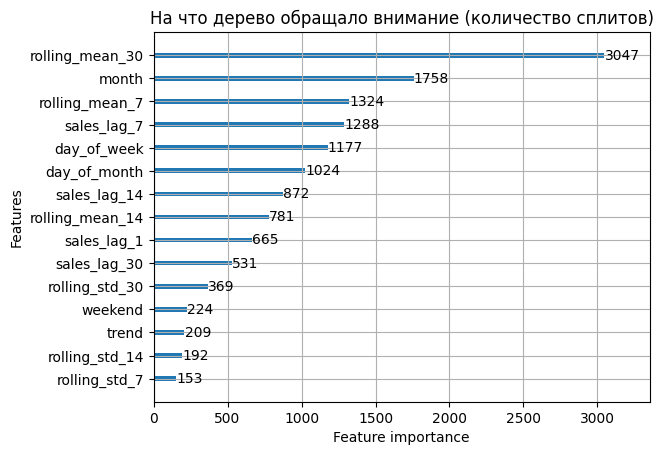

In [380]:
lgb.plot_importance(lgb_model_robust, max_num_features=15, importance_type='split')
plt.title("На что дерево обращало внимание (количество сплитов)")
plt.show()

Дав ограничения модели, она не перестала в основном опираться на среднее за 30 дней: слишком жёсткие ограничения лишь сильнее ухудшат модель. Основная проблема в том, что за основу она взяла очень размытую фичу, которая сильно сгладила остальные тренды. Есть две идеи что можно улучшить:
1. переделать таргет и давать модели явные sales и поменять метрику для оптимизации с MSE на MAPE 
2. явно подсказать модели опираться на более свежие значения, а не на простое среднее (экспоненциальное затухание).

Пересоберём данные под новые установки:
* добавим экспоненциальное затухание с периодами 7, 14, 30;
* добавим momentum как разницу `rolling_mean_7` и `rolling_mean_30`.

In [ ]:
df_train_tr = df_train.copy()
df_train_tr['date'] = pd.to_datetime(df_train_tr['date'])
df_train_tr['day_of_week'] = df_train_tr['date'].dt.dayofweek # 0 - Понедельник, 6 - Воскресенье
df_train_tr['day_of_month'] = df_train_tr['date'].dt.day  
df_train_tr['month'] = df_train_tr['date'].dt.month
df_train_tr['year'] = df_train_tr['date'].dt.year
df_train_tr['weekend'] = (df_train_tr['day_of_week'] > 4).astype(int)
# Сортируем по магазинам, товарам и дате
df_train_tr = df_train_tr.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)
# Для каждой пары (store, item) создаем счетчик от 0 до N
df_train_tr['trend'] = df_train_tr.groupby(['store', 'item']).cumcount()
# ДЕЛАЕМ УМНОЕ СРЕДНЕЕ (Экспоненциальное затухание)
# span=30 означает "учитывай примерно 30 дней, но с затуханием"
df_train_tr['ewm_30'] = df_train_tr.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=30, min_periods=1).mean()
)

# Можно сделать быстрый EWM на 7 дней (очень чуткий к последним дням)
df_train_tr['ewm_7'] = df_train_tr.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=7, min_periods=1).mean()
)

df_train_tr['ewm_14'] = df_train_tr.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=14, min_periods=1).mean()
)

lags = [1, 7, 14, 30]

# Create features
df_train_tr = create_lag_features(df_train_tr, lags)

# Define windows
windows = [7, 14, 30]

# Create features
df_train_tr = create_rolling_features(df_train_tr, windows)
df_train_tr_clear = df_train_tr.dropna()

df_train_tr_clear['target_log'] = np.log1p(df_train_tr_clear['sales'])
# 1. Делаем One-Hot Encoding для категорий 
df_ohe = pd.get_dummies(df_train_tr_clear, columns=['store', 'item'], drop_first=True)


df_ohe['momentum'] = df_ohe['rolling_mean_7'] - df_ohe['rolling_mean_30']
# 2. Разделяем фичи на числовые и категориальные
numeric_features = ['year','sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'weekend', 'month', 'day_of_week', 'day_of_month', 'trend', 'momentum', 
       'ewm_30', 'ewm_14','ewm_7']

# Собираем названия всех OHE столбцов, которые сгенерировал pandas
categorical_features = [col for col in df_ohe.columns if col.startswith('store_') or col.startswith('item_')]

X_numeric = df_ohe[numeric_features]
X_categorical = df_ohe[categorical_features]
y = df_ohe['sales']
split_date = '2017-10-01'

mask_train = df_ohe['date'] < split_date
mask_test = df_ohe['date'] >= split_date

# Разбиваем числовые фичи
X_num_train = X_numeric[mask_train]
X_num_test = X_numeric[mask_test]

# Разбиваем категориальные фичи (OHE)
X_cat_train = X_categorical[mask_train]
X_cat_test = X_categorical[mask_test]

# Разбиваем таргет
y_train = y[mask_train]
y_test = y[mask_test]

# 5. СКЛЕИВАЕМ нормализованные числа и ненормализованные OHE (нули и единицы)
X_train_final = pd.concat([X_num_train, X_cat_train], axis=1)
X_test_final = pd.concat([X_num_test, X_cat_test], axis=1)

In [382]:
lgb_model_balanced = lgb.LGBMRegressor(
    # 1. Сбалансированная сложность
    objective='mape',
    max_depth=7,              # Чуть больше свободы (было 5)
    num_leaves=31,            # Возвращаем дефолт (оставляем модель цепляться за взаимодействия)
    min_child_samples=50,     # Снижаем требование к минимуму данных в листе (было 100)
    
    # 2. Легкая регуляризация (почти как дефолт)
    reg_alpha=0.1,            # Очень легкий штраф
    reg_lambda=0.1,           # Очень легкий штраф
    
    # 3. Случайность (ОБЯЗАТЕЛЬНО оставляем)
    colsample_bytree=0.7,     
    subsample=0.7,            
    
    # 4. Обучение
    learning_rate=0.03,       # Оставляем мелкий шаг для стабильности
    n_estimators=1000,        
    random_state=42,
    n_jobs=-1
)

print("Обучение сбалансированного LightGBM...")
lgb_model_balanced.fit(X_train_final, y_train)

# Предсказание
preds_robust_log = lgb_model_balanced.predict(X_test_final)
preds_robust_real = np.expm1(preds_robust_log)

# Оценка по отрезкам (смотрим, побороли ли инерцию)
mask_for_mape = y_test > 0

mape_robust_first_30 = mean_absolute_percentage_error(y_test[:15000][mask_for_mape[:15000]], preds_robust_log[:15000][mask_for_mape[:15000]])
mape_robust_last_30 = mean_absolute_percentage_error(y_test[-15000:][mask_for_mape[-15000:]], preds_robust_log[-15000:][mask_for_mape[-15000:]])
mape_robust_total = mean_absolute_percentage_error(y_test[mask_for_mape], preds_robust_log[mask_for_mape])
print(f"\n=== РЕЗУЛЬТАТЫ ROBUST LightGBM ===")
print(f"Общий MAPE: {mape_robust_total*100:.2f}%")
print(f"Первые 30 дней (Инерция): {mape_robust_first_30*100:.2f}%") 
print(f"Последние 30 дней (Сезон): {mape_robust_last_30*100:.2f}%") 


Обучение сбалансированного LightGBM...

=== РЕЗУЛЬТАТЫ ROBUST LightGBM ===
Общий MAPE: 12.85%
Первые 30 дней (Инерция): 12.18%
Последние 30 дней (Сезон): 12.18%


Принципиальных изменений не наблюдаю, нужно посмотеть на значимость признаков для модели

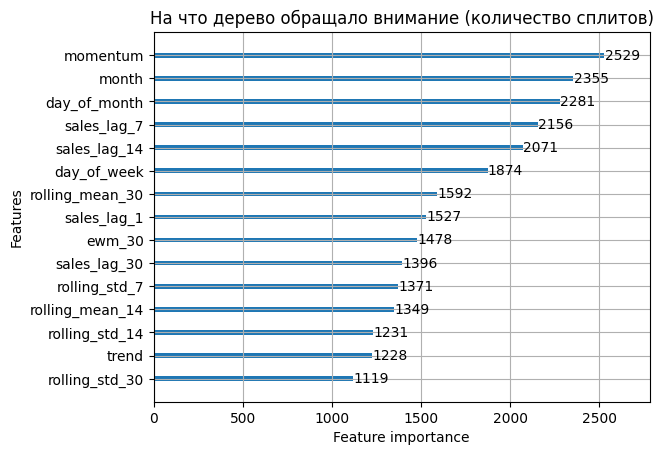

In [383]:
lgb.plot_importance(lgb_model_balanced, max_num_features=15, importance_type='split')
plt.title("На что дерево обращало внимание (количество сплитов)")
plt.show()

Теперь хорошо видно, что модель работает с близкими признаками и больше обращает внимания на сам тренд

В ходе экспериментов было установлено, что использование логарифмирования таргета (log1p) с стандартной MSE-функцией потерь дает MAPE = 12.8%. Прямая оптимизация MAPE на исходных данных дает MAPE = 12.85%.

Поскольку разница в метриках статистически незначима, в качестве финальной модели выбран LightGBM с objective='mape' без логарифмирования таргета.
Отказ от log1p/expm1 упрощает пайплайн предсказаний и снижает latency.
Исключается риск "отрицательных продаж", который возникает при expm1 от отрицательных предсказаний дерева.
Модель напрямую оптимизирует бизнес-метрику (процент ошибки), а не ее математический суррогат. 
Так же последняя врсия модели стала больше внимания обращать на сам тренд 

In [387]:
df_train_lr_clear['target_log'] = np.log1p(df_train_lr_clear['sales'])

# 1. Делаем One-Hot Encoding
df_ohe = pd.get_dummies(df_train_lr_clear, columns=['store', 'item'], drop_first=True)
df_ohe['ewm_30'] = df_train_lr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=30, min_periods=1).mean()
)

df_ohe['ewm_7'] = df_train_lr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=7, min_periods=1).mean()
)

df_ohe['ewm_14'] = df_train_lr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=14, min_periods=1).mean()
)
df_ohe = df_ohe.dropna(subset=['ewm_7', 'ewm_14', 'ewm_30'])
# 2. Списки фичей
numeric_features = ['sin_week', 'cos_week', 'sin_month',
       'cos_month', 'year', 'trend', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'trend_sqrt', 'trend_sq', 'ewm_7', 'ewm_14', 'ewm_30']

categorical_features = [col for col in df_ohe.columns if col.startswith('store_') or col.startswith('item_')]

# 3. ИЗВЛЕКАЕМ ДАННЫЕ КАК DATAFRAME, А НЕ КАК СПИСОК
y = df_ohe['target_log']
X_numeric = df_ohe[numeric_features]
X_categorical = df_ohe[categorical_features] 

# 4. НОРМАЛИЗУЕМ ЧИСЛОВЫЕ ФИЧИ
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# берем индекс прямо из df_ohe, чтобы ничего не потерять
X_numeric_scaled = pd.DataFrame(X_numeric_scaled, columns=numeric_features, index=df_ohe.index)

# 5. СКЛЕИВАЕМ (Теперь склеиваем два DataFrame)
X_lr_full = pd.concat([X_numeric_scaled, X_categorical], axis=1)



dates = df_ohe['date'] 

unique_test_days = sorted(dates.unique())[-92:]

mape_lr_list = []
mape_lgbm_list = []

model_lr = LinearRegression(n_jobs=-1)

print(f"Запуск симуляции PROD на {len(unique_test_days)} дней...\n")

for i, current_day in enumerate(unique_test_days):
    
    train_mask = dates < current_day
    test_mask = dates == current_day
    
    X_train = X_lr_full[train_mask]
    y_train = y[train_mask]
    
    X_test = X_lr_full[test_mask]
    y_test_log = y[test_mask]
    y_test_real = np.expm1(y_test_log)
    
    valid_mask = y_test_real > 0
    y_test_valid = y_test_real[valid_mask]
    
    # --- Линейная Регрессия ---
    model_lr.fit(X_train, y_train)
    preds_lr_real = np.expm1(model_lr.predict(X_test))
    
    if len(y_test_valid) > 0:
        mape_lr_list.append(mean_absolute_percentage_error(y_test_valid, preds_lr_real[valid_mask]))

    if (i+1) % 10 == 0 or i == 0:
        print(f"День {i+1}/{len(unique_test_days)} | MAPE LR: {np.mean(mape_lr_list[-10:]):.2%}")

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СИМУЛЯЦИИ PRODUCTION (Walk-Forward)")
print("="*50)
print(f"Линейная Регрессия Средний MAPE: {np.mean(mape_lr_list):.2%}")

Запуск симуляции PROD на 92 дней...

День 1/92 | MAPE LR: 12.50%
День 10/92 | MAPE LR: 13.85%
День 20/92 | MAPE LR: 13.36%
День 30/92 | MAPE LR: 13.23%
День 40/92 | MAPE LR: 16.90%
День 50/92 | MAPE LR: 14.49%
День 60/92 | MAPE LR: 14.46%
День 70/92 | MAPE LR: 20.19%
День 80/92 | MAPE LR: 16.47%
День 90/92 | MAPE LR: 17.10%

РЕЗУЛЬТАТЫ СИМУЛЯЦИИ PRODUCTION (Walk-Forward)
Линейная Регрессия Средний MAPE: 15.55%


In [ ]:
# 1. Делаем One-Hot Encoding
df_ohe = pd.get_dummies(df_train_tr_clear, columns=['store', 'item'], drop_first=True)

df_ohe['ewm_30'] = df_train_tr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=30, min_periods=1).mean()
)
df_ohe['ewm_7'] = df_train_tr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=7, min_periods=1).mean()
)
df_ohe['ewm_14'] = df_train_tr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).ewm(span=14, min_periods=1).mean()
)

df_ohe['rolling_mean_7'] = df_train_tr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)
df_ohe['rolling_mean_30'] = df_train_tr_clear.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=30, min_periods=1).mean()
)

df_ohe['momentum'] = df_ohe['rolling_mean_7'] - df_ohe['rolling_mean_30']

# 2. Списки фичей
numeric_features = ['year','sales_lag_1', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30',
       'rolling_std_30', 'weekend', 'month', 'day_of_week', 'day_of_month', 
       'trend', 'momentum', 'ewm_30', 'ewm_14','ewm_7']

categorical_features = [col for col in df_ohe.columns if col.startswith('store_') or col.startswith('item_')]

# 3. ИЗВЛЕКАЕМ ДАННЫЕ (БЕЗ ЛОГАРИФМА)
y = df_train_tr_clear['sales'] 
X_numeric = df_ohe[numeric_features]
X_categorical = df_ohe[categorical_features]

# 4. СКЛЕИВАЕМ БЕЗ НОРМАЛИЗАЦИИ 
X_lgbm_full = pd.concat([X_numeric, X_categorical], axis=1) 

# --- НАСТРОЙКА МОДЕЛИ ---

dates = df_ohe['date'] 
unique_test_days = sorted(dates.unique())[-92:]

mape_lgbm_list = []

model_lgbm = lgb.LGBMRegressor(
    objective='mape',
    max_depth=7,              
    num_leaves=31,            
    min_child_samples=50,     
    reg_alpha=0.1,            
    reg_lambda=0.1,           
    colsample_bytree=0.7,     
    subsample=0.7,            
    learning_rate=0.03,       
    n_estimators=1000,        
    random_state=42,
    n_jobs=-1,
    verbose=-1,               
    force_col_wise=True       
)

print(f"Запуск абсолютно тихой симуляции PROD на {len(unique_test_days)} дней")

for i, current_day in enumerate(unique_test_days):
    
    train_mask = dates < current_day
    test_mask = dates == current_day
    
    X_train = X_lgbm_full[train_mask]
    y_train = y[train_mask]
    
    X_test = X_lgbm_full[test_mask]
    y_test_real = y[test_mask] 
    
    valid_mask = y_test_real > 0
    y_test_valid = y_test_real[valid_mask]
    
    # --- LightGBM ---
    model_lgbm.fit(X_train, y_train)
    preds_lgbm_raw = model_lgbm.predict(X_test)
    
    # Защита от отрицательных предсказаний 
    preds_lgbm_real = np.maximum(0, preds_lgbm_raw) 
    
    if len(y_test_valid) > 0:
        mape_lgbm_list.append(mean_absolute_percentage_error(y_test_valid, preds_lgbm_real[valid_mask]))

    # Выводим прогресс без мусора
    if (i+1) % 10 == 0 or i == 0:
        print(f"День {i+1}/{len(unique_test_days)} | MAPE LGBM: {np.mean(mape_lgbm_list[-10:]):.2%}")

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СИМУЛЯЦИИ PRODUCTION (Walk-Forward)")
print("="*50)
print(f"LightGBM Средний MAPE: {np.mean(mape_lgbm_list):.2%}")

Запуск абсолютно тихой симуляции PROD на 92 дней
День 1/92 | MAPE LGBM: 11.78%
День 10/92 | MAPE LGBM: 12.70%
День 20/92 | MAPE LGBM: 12.29%
День 30/92 | MAPE LGBM: 12.06%
День 40/92 | MAPE LGBM: 12.39%
День 50/92 | MAPE LGBM: 11.56%
День 60/92 | MAPE LGBM: 11.96%
День 70/92 | MAPE LGBM: 14.11%
День 80/92 | MAPE LGBM: 14.02%
День 90/92 | MAPE LGBM: 14.26%

РЕЗУЛЬТАТЫ СИМУЛЯЦИИ PRODUCTION (Walk-Forward)
LightGBM Средний MAPE: 12.85%


В рамках работы была проведена комплексная оценка подходов к прогнозированию временных рядов с множественными сущностями (10 магазинов, 50 товаров). Основной фокус был сделан на сравнении классической линейной модели и ансамблевых методов деревьев решений в двух режимах: статическом разрезе и симуляции production-цикла.

1. Выбор архитектуры: Глобальная против Локальной
Сравнение Глобальной Линейной Регрессии (MAPE 15.8%) и подхода с обучением отдельных моделей для каждой пары "Магазин-Товар" (MAPE 18.0%) наглядно доказало преимущество глобального обучения. Алгоритм выгоднее извлекать "коллективный опыт" из всех 500 комбинаций, подстраивая веса под общие паттерны, чем пытаться подбирать параметры изолированно на ограниченных выборках.

2. Влияние Feature Engineering и нелинейности
Базовый Случайный лес показал результат 13.86%, а LightGBM — 12.86%, уверенно обойдя Линейную Регрессию. Этот прирост достигнут исключительно за счет архитектуры алгоритмов: деревья смогли найти нелинейные взаимосвязи (например, взаимодействие дня месяца, дня недели и конкретного магазина), которые линейная модель не способна уловить без сложного ручного создания признаков-флагов.

3. Устойчивость LightGBM к гиперпараметрам
В ходе экспериментов было выявлено, что LightGBM продемонстрировал феноменальную независимость от настроек регуляризации и трансформации таргета:

Базовая версия с логарифмом: 12.86%
Версия с жесткими штрафами и логарифмом: 12.90%
Балансированная версия БЕЗ логарифма таргета: 12.85%
Разброс в 0.05% свидетельствует о том, что созданный пайплайн признаков (в частности, использование экспоненциального сглаживания EWM и правильно вычисленных лагов) содержит настолько сильный предиктивный сигнал, что алгоритму не требуется сложная калибровка. Это гарантирует простоту и безопасность внедрения модели.

4. Симуляция Production (Walk-Forward Validation)
Ключевым этапом стала проверка гипотезы о необходимости ежедневного дообучения (MLOps). Симуляция 92-дневного прогноза с переобучением на каждый новый день дала поразительный результат:

Линейная Регрессия: Статика 15.8% 
→
 Walk-Forward 15.55%
LightGBM: Статика 12.85% 
→
 Walk-Forward 12.85%
Метрики практически не изменились. Это доказывает, что обе модели являются feature-driven (управляемыми признаками), а не data-driven. Вся предиктивная сила заложена в актуальных значениях лагов и скользящих средних, а не в весах, подстраивающихся под новые данные. Это полностью снимает необходимость строить сложную инфраструктуру для ежедневного переобучения.

5. Поведение в условиях волатильности
Анализ динамики ошибок по дням выявил слабое место линейного подхода. На 70-й день теста (период резкого роста продаж) Линейная Регрессия показала критический провал до 20.19%, в то время как LightGBM удержал ошибку на уровне 14.11%. Деревья решений справляются со стресс-тестами рынка значительно надежнее за счет нелинейной сегментации пиковых значений.

Итоговое решение:
В качестве финальной модели выбран LightGBM базовой конфигурации без логарифмирования таргета.
Выбор обоснован стабильным преимуществом в 2.7 процентных пункта над Линейной Регрессией (12.85% против 15.55% в прод-симуляции) при равной устойчивости на длинных горизонтах. Отсутствие необходимости в логарифмировании и ежедневном переобучении делает решение максимально легковесным, быстрым и готовым к деплою "как есть".

## Тут могла быть ваша ~~реклама~~ SARIMA

Можно было заметить, что в ноутбуке нет тестов модели SARIMA (на самом деле они здесь были), хотя в самом начале я хотел сравнить её с классическими ML-моделями. Проблема оказалась в методе обучения: как говорил в начале, в датасете есть 500 комбинаций магазин/товар, и для обучения SARIMA не остаётся ничего, кроме как обучать 500 моделей. Вроде бы проблемы нет — ту же линейную модель я обучал на каждой комбинации, **но** обучение линейных моделей заняло 5 минут, когда SARIMA затрачивает на это 30 часов. Для меня это плохая новость. Всё-таки я попробовал обучить эти модели в меньшем количестве: обучил около 200 моделей за 11 часов, и, честно говоря, проблемы на этом не заканчиваются.

**Проблема 1**
* SARIMA должна заранее знать сезонность (для меня это оказалось странным). Верхнеуровнево узнать сезонность заранее почти не проблема, но не для 500 моделей. Также увеличение этого параметра сильно удлиняет время обучения.

**Проблема 2**
* Плавно вытекает из проблемы 1: мы не можем задать несколько сезонов. По идее продажи товаров могут иметь и недельную, и месячную, и годовую сезонность, а заложить это в SARIMA мы, к сожалению, не можем.

**Проблема 3**
* Средний MAPE составил 33% (с аномальными выбросами до 90%). Деконструкция этих ошибок показала, что причина кроется не в отсутствии данных, а в фундаментальных ограничениях статистического аппарата SARIMA:
  * алгоритм массово применял избыточное дифференцирование (d=2, D=2) на длинных рядах, превращая сигнал в шум;
  * линейная природа SARIMA не позволила модели улавливать резкие нелинейные пики спроса (праздничные аномалии), которые составляют основную долю ошибки в метрике MAPE.

**Но не всё так плохо, как может показаться:**
* SARIMA не требует feature engineering — для запуска достаточно исторического ряда, без отдельного пайплайна подготовки признаков;
* в SARIMA мы можем предсказывать любой горизонт t+h. Линейная модель и градиентный бустинг, которые использовались в ноутбуке, в текущей постановке предсказывают только t+1, что, честно говоря, слишком «рядом». Да, эти модели можно переделать под t+2 или t+3, но это снова работа с признаками и повторное обучение и тестирование, тогда как у SARIMA это доступно «из коробки»;
* у SARIMA есть суперсила, которой нет у обычной LR или LightGBM: она по умолчанию выдаёт не просто точку, а распределение вероятностей (confidence intervals — доверительные интервалы).